In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn 
import seaborn as sns

In [2]:
cars_file = 'https://gist.githubusercontent.com/noamross/e5d3e859aa0c794be10b/raw/b999fb4425b54c63cab088c0ce2c0d6ce961a563/cars.csv'
cars = pd.read_csv(cars_file)
cars.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


<Axes: xlabel='wt', ylabel='mpg'>

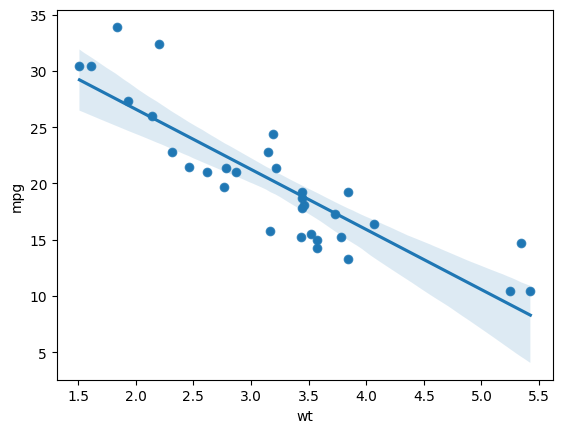

In [3]:
sns.scatterplot(x='wt', y='mpg', data=cars)
sns.regplot(x='wt', y='mpg', data=cars)

In [ ]:
X_list = cars.wt.values
X_np = np.array(X_list, dtype=np.float32).reshape(-1,1)
y_list = cars.mpg.values
y_np = np.array(y_list, dtype=np.float32).reshape(-1,1)

X = torch.from_numpy(X_np)
y_true = torch.from_numpy(y_np)

In [ ]:
class LinearRegression(nn.Module):
    def __init__(self, input_size, output_size):
        
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)
    
    def forward(self, x):
        return self.linear(x)
    

input_dim = 1
output_dim = 1
model = LinearRegression(input_size=input_dim, output_size=output_dim)

In [ ]:
loss_fun = nn.MSELoss()

LR = 0.02

optimizer = torch.optim.SGD(model.parameters(), lr=LR)

In [ ]:
losses, slope, bias = [], [], []
NUM_EPOCHS = 1000
for epoch in range(NUM_EPOCHS):
    
    # set gradients to zero
    optimizer.zero_grad()

    # forward pass
    y_pred = model(X)

    # calculate loss
    loss = loss_fun(y_pred, y_true)
    loss.backward()

    # update parameters
    optimizer.step()

    # get parameters
    for name, param in model.named_parameters():
        if param.requires_grad:
            if name == 'linear.weight':
                slope.append(param.data.numpy()[0][0])
            if name == 'linear.bias':
                bias.append(param.data.numpy()[0])


    # store loss
    losses.append(float(loss.data))

    # print loss
    if (epoch % 100 == 0):
        print(f"Epoch {epoch}, Loss: {loss.data}")

Epoch 0, Loss: 478.5421447753906
Epoch 100, Loss: 63.97920227050781
Epoch 200, Loss: 38.765235900878906
Epoch 300, Loss: 25.051366806030273
Epoch 400, Loss: 17.59239959716797
Epoch 500, Loss: 13.535453796386719
Epoch 600, Loss: 11.328893661499023
Epoch 700, Loss: 10.128745079040527
Epoch 800, Loss: 9.475982666015625
Epoch 900, Loss: 9.120942115783691


<Axes: >

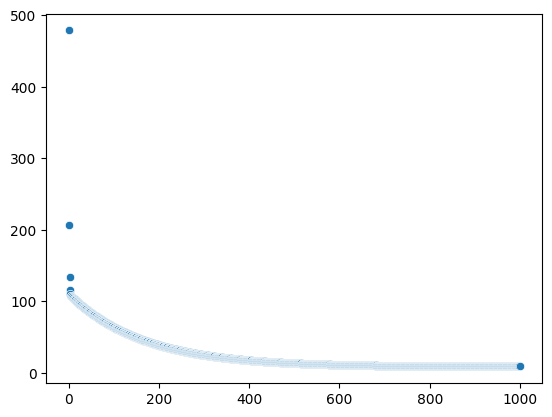

In [8]:
sns.scatterplot(x=range(NUM_EPOCHS), y=losses)

<Axes: >

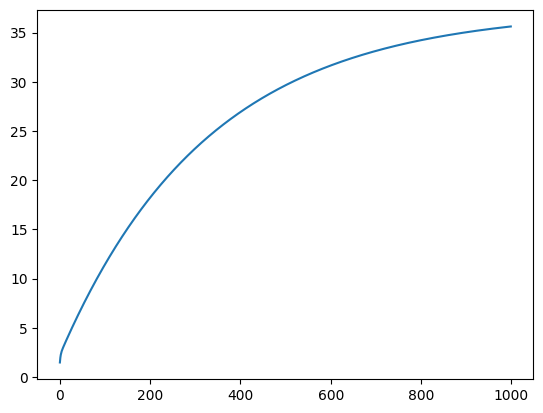

In [9]:
sns.lineplot(x=range(NUM_EPOCHS), y=bias)

<Axes: >

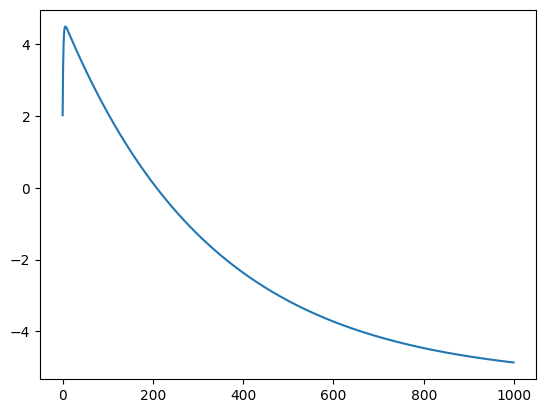

In [10]:
sns.lineplot(x=range(NUM_EPOCHS), y=slope)

<Axes: >

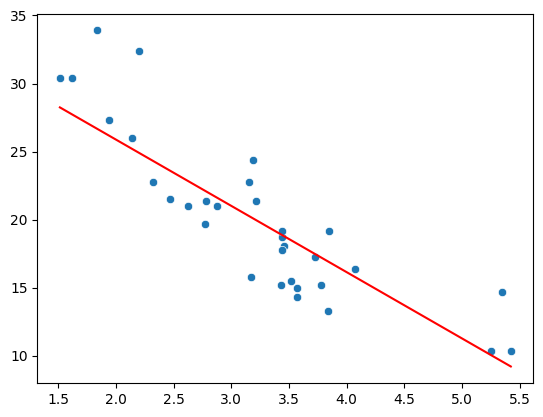

In [ ]:
y_pred = model(X).data.numpy().reshape(-1)

sns.scatterplot(x=X_list, y=y_list)
sns.lineplot(x=X_list, y=y_pred, color='red')